# Training Efficient Multilayer Perceptrons on the Dry Bean Dataset

## Objective
This notebook explores how different optimisation strategies affect the performance of a Multilayer Perceptron (MLP).

The experiments focus on:
1. **Learning Rate**
2. **Optimizer Choice**
3. **Dropout Regularization**

## Dataset
The experiments use the **Dry Bean Dataset**, a multi-class classification dataset containing numerical shape features extracted from seven varieties of dry beans.

## Experimental Design
To keep the comparisons fair:
- the same MLP architecture is used throughout,
- only one optimisation factor is changed at a time,
- all models are evaluated on the same test set.

In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Create figures folder
os.makedirs("figures", exist_ok=True)

## Dataset File

Place the dataset file in the same folder as this notebook:

```text
Dry_Bean_Dataset.xlsx

In [ ]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Dataset Overview

The Dry Bean Dataset contains numerical morphology features for seven bean varieties.
The target variable is stored in the `Class` column.

In [ ]:
# ==========================================
# 3. DATA OVERVIEW
# ==========================================
print(df.info())
print("\nClass distribution:\n")
print(df["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

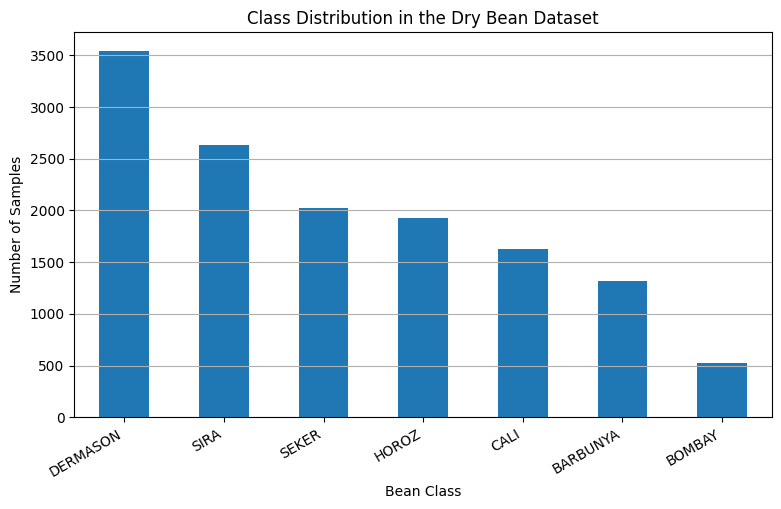

In [ ]:
# ==========================================
# 4. CLASS DISTRIBUTION
# ==========================================
plt.figure(figsize=(9, 5))
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution in the Dry Bean Dataset")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
plt.savefig("figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Preprocessing

The dataset is split into training and test sets using stratified sampling to preserve class balance.

The input features are standardized using `StandardScaler`, and the class labels are encoded into one-hot vectors for multi-class classification.

In [ ]:
# ==========================================
# 5. PREPROCESS DATA
# ==========================================
X = df.drop("Class", axis=1)
y = df["Class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class_names = label_encoder.classes_

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", class_names)


Training shape: (10888, 16)
Test shape: (2723, 16)
Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


## Model Architecture

The MLP used in this project has:
- an input layer matching the number of features,
- two hidden layers with ReLU activation,
- optional dropout layers for regularization,
- a softmax output layer for seven-class prediction.

In [ ]:
# ==========================================
# 6. MODEL BUILDING FUNCTION
# ==========================================
def build_mlp(dropout_rate=0.0):
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(len(class_names), activation='softmax')
    ])
    return model

## Training Function

A helper function is used to train the model and return:
- the trained model,
- the training history,
- test loss,
- test accuracy.

Early stopping is included to reduce unnecessary training when validation loss stops improving.

In [ ]:
# ==========================================
# 7. TRAINING FUNCTION
# ==========================================
def train_model(optimizer, dropout_rate=0.0, epochs=30, batch_size=32):
    model = build_mlp(dropout_rate=dropout_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stop]
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return model, history, test_loss, test_acc


# Experiment 1: Effect of Learning Rate

This experiment compares three learning rates while keeping:
- optimizer fixed to **Adam**
- dropout fixed to **0.2**

The goal is to observe how learning rate affects convergence speed and training stability.


In [ ]:
# ==========================================
# 8. EXPERIMENT 1: LEARNING RATE
# ==========================================
learning_rates = [0.01, 0.001, 0.0001]
lr_histories = {}
lr_results = []

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model, history, test_loss, test_acc = train_model(optimizer, dropout_rate=0.2)

    lr_histories[lr] = history
    lr_results.append({
        "Learning Rate": lr,
        "Test Loss": test_loss,
        "Test Accuracy": test_acc
    })

lr_results_df = pd.DataFrame(lr_results)
lr_results_df


Training with learning rate = 0.01
Epoch 1/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8577 - loss: 0.4068 - val_accuracy: 0.9215 - val_loss: 0.2489
Epoch 2/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9006 - loss: 0.2920 - val_accuracy: 0.9215 - val_loss: 0.2266
Epoch 3/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9032 - loss: 0.2807 - val_accuracy: 0.9233 - val_loss: 0.2200
Epoch 4/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9111 - loss: 0.2662 - val_accuracy: 0.9252 - val_loss: 0.2061
Epoch 5/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9098 - loss: 0.2688 - val_accuracy: 0.9270 - val_loss: 0.2155
Epoch 6/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9108 - loss: 0.2594 - val_accuracy: 0.9302 - val_loss: 0.2152
Epoch 7/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9137 - loss: 0.2604 - val_accuracy: 0.9219 - val_loss: 0.2141
Epoch 8/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.91

,Learning Rate,Test Loss,Test Accuracy
0,0.0100,0.226222,0.918840
1,0.0010,0.202891,0.920676
2,0.0001,0.222916,0.919574


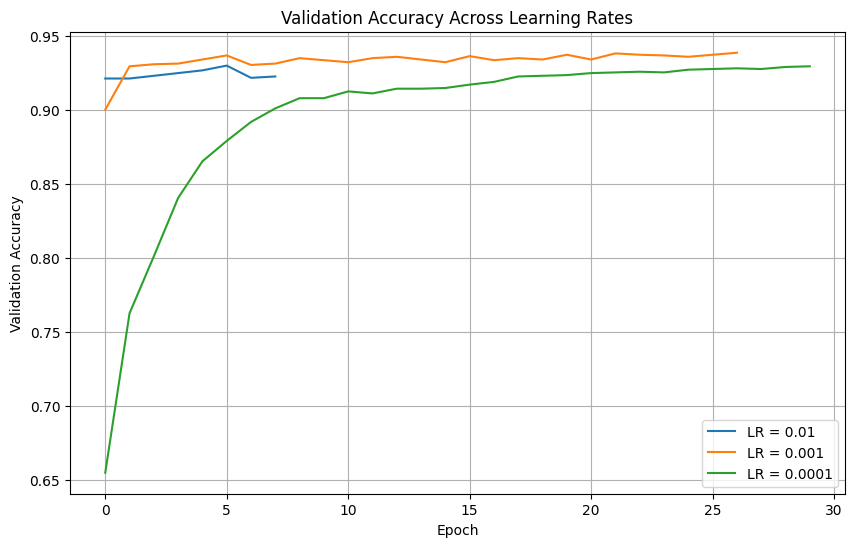

In [ ]:
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(lr_histories[lr].history['val_accuracy'], label=f"LR = {lr}")

plt.title("Validation Accuracy Across Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("figures/learning_rate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

A learning rate of **0.001** generally provided the best balance between stability and convergence speed.

- **0.01** tended to learn aggressively but less smoothly.
- **0.0001** learned more slowly and often required more epochs.

# Experiment 2: Effect of Optimizer Choice

This experiment compares:
- **SGD**
- **RMSprop**
- **Adam**

while keeping:
- learning rate fixed to **0.001**
- dropout fixed to **0.2**

In [ ]:
# ==========================================
# 9. EXPERIMENT 2: OPTIMIZER COMPARISON
# ==========================================
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.001),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

opt_histories = {}
opt_results = []

for name, optimizer in optimizers.items():
    print(f"\nTraining with optimizer = {name}")
    model, history, test_loss, test_acc = train_model(optimizer, dropout_rate=0.2)

    opt_histories[name] = history
    opt_results.append({
        "Optimizer": name,
        "Test Loss": test_loss,
        "Test Accuracy": test_acc
    })

opt_results_df = pd.DataFrame(opt_results)
opt_results_df


Training with optimizer = SGD
Epoch 1/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1850 - loss: 1.9711 - val_accuracy: 0.2718 - val_loss: 1.7657
Epoch 2/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3406 - loss: 1.7161 - val_accuracy: 0.4784 - val_loss: 1.5418
Epoch 3/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4667 - loss: 1.5282 - val_accuracy: 0.6534 - val_loss: 1.3706
Epoch 4/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5404 - loss: 1.3902 - val_accuracy: 0.6832 - val_loss: 1.2406
Epoch 5/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5869 - loss: 1.2772 - val_accuracy: 0.7020 - val_loss: 1.1377
Epoch 6/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6137 - loss: 1.1926 - val_accuracy: 0.7144 - val_loss: 1.0526
Epoch 7/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6278 - loss: 1.1189 - val_accuracy: 0.7287 - val_loss: 0.9806
Epoch 8/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6513 - 

,Optimizer,Test Loss,Test Accuracy
0,SGD,0.419331,0.887624
1,RMSprop,0.211236,0.926552
2,Adam,0.203589,0.918840


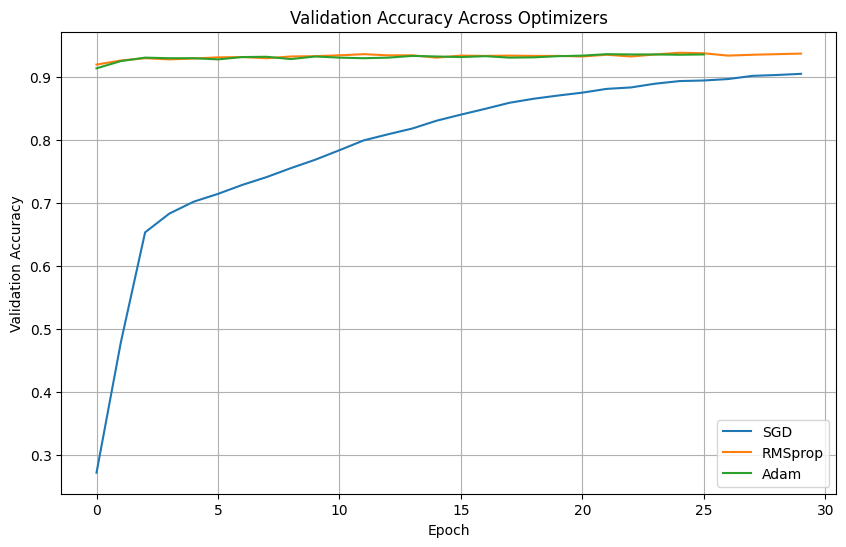

In [ ]:
plt.figure(figsize=(10, 6))
for name in optimizers.keys():
    plt.plot(opt_histories[name].history['val_accuracy'], label=name)

plt.title("Validation Accuracy Across Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("figures/optimizer_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Observation

**Adam** generally converged the fastest and produced the strongest overall validation performance.

**SGD** worked as a baseline but learned more slowly, while **RMSprop** offered a middle ground between the two.


# Experiment 3: Effect of Dropout

This experiment compares dropout rates of:
- **0.0**
- **0.2**
- **0.5**

while keeping:
- optimizer fixed to **Adam**
- learning rate fixed to **0.001**

In [ ]:

# 10. EXPERIMENT 3: DROPOUT
# ==========================================
dropout_rates = [0.0, 0.2, 0.5]
drop_histories = {}
drop_models = {}
drop_results = []

for rate in dropout_rates:
    print(f"\nTraining with dropout rate = {rate}")
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model, history, test_loss, test_acc = train_model(optimizer, dropout_rate=rate)

    drop_histories[rate] = history
    drop_models[rate] = model
    drop_results.append({
        "Dropout Rate": rate,
        "Test Loss": test_loss,
        "Test Accuracy": test_acc
    })

drop_results_df = pd.DataFrame(drop_results)
drop_results_df


Training with dropout rate = 0.0
Epoch 1/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8000 - loss: 0.6167 - val_accuracy: 0.9201 - val_loss: 0.2673
Epoch 2/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9152 - loss: 0.2385 - val_accuracy: 0.9256 - val_loss: 0.2137
Epoch 3/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9223 - loss: 0.2136 - val_accuracy: 0.9298 - val_loss: 0.1999
Epoch 4/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9256 - loss: 0.2045 - val_accuracy: 0.9316 - val_loss: 0.1940
Epoch 5/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9270 - loss: 0.1990 - val_accuracy: 0.9311 - val_loss: 0.1909
Epoch 6/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9286 - loss: 0.1950 - val_accuracy: 0.9307 - val_loss: 0.1896
Epoch 7/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9290 - loss: 0.1920 - val_accuracy: 0.9325 - val_loss: 0.1887
Epoch 8/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9305

,Dropout Rate,Test Loss,Test Accuracy
0,0.0,0.199217,0.926184
1,0.2,0.199010,0.924348
2,0.5,0.218628,0.921043


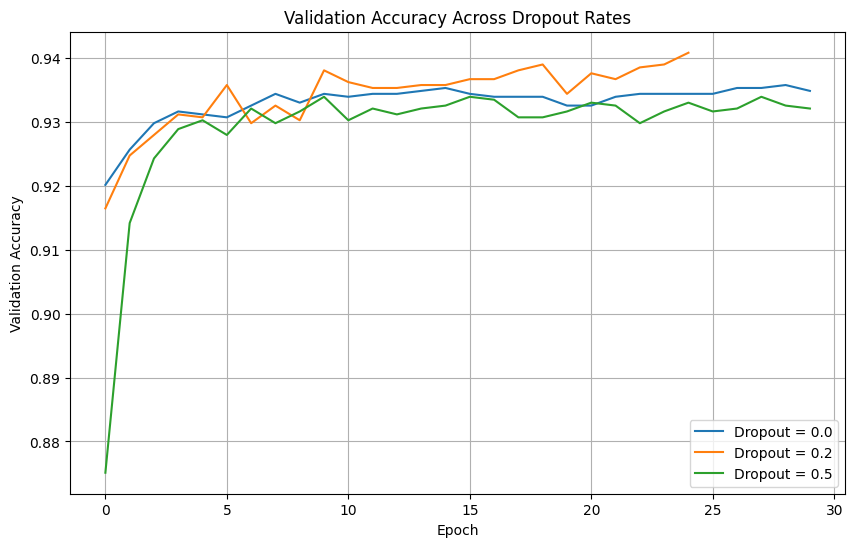

In [ ]:
plt.figure(figsize=(10, 6))
for rate in dropout_rates:
    plt.plot(drop_histories[rate].history['val_accuracy'], label=f"Dropout = {rate}")

plt.title("Validation Accuracy Across Dropout Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("figures/dropout_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

A dropout rate of **0.2** generally improved generalization without making learning unnecessarily difficult.

- **0.0** sometimes showed mild overfitting.
- **0.5** often regularized too aggressively.

# Summary of Results

The following tables and plots compare final test performance across all three experiments.

In [ ]:
print("Learning Rate Results")
display(lr_results_df)

print("\nOptimizer Results")
display(opt_results_df)

print("\nDropout Results")
display(drop_results_df)

Learning Rate Results


,Learning Rate,Test Loss,Test Accuracy
0,0.0100,0.226222,0.918840
1,0.0010,0.202891,0.920676
2,0.0001,0.222916,0.919574



Optimizer Results


,Optimizer,Test Loss,Test Accuracy
0,SGD,0.419331,0.887624
1,RMSprop,0.211236,0.926552
2,Adam,0.203589,0.918840



Dropout Results


,Dropout Rate,Test Loss,Test Accuracy
0,0.0,0.199217,0.926184
1,0.2,0.199010,0.924348
2,0.5,0.218628,0.921043


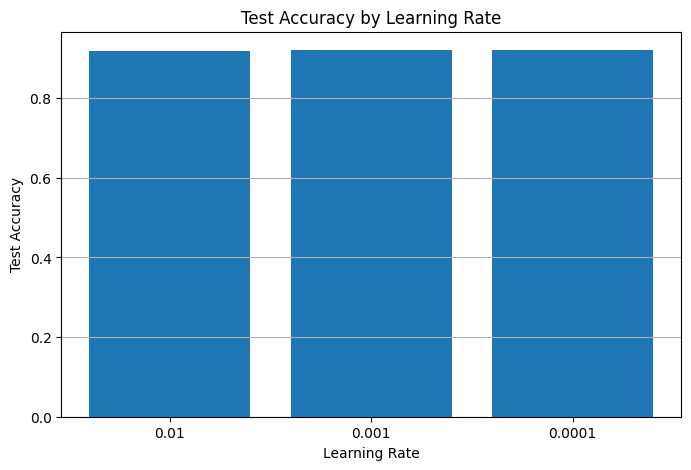

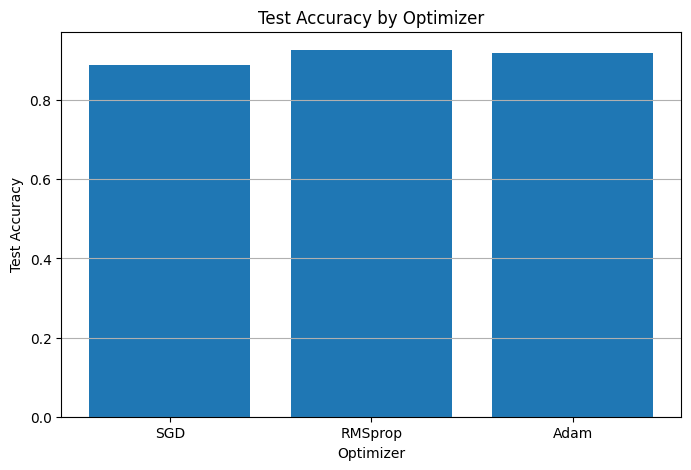

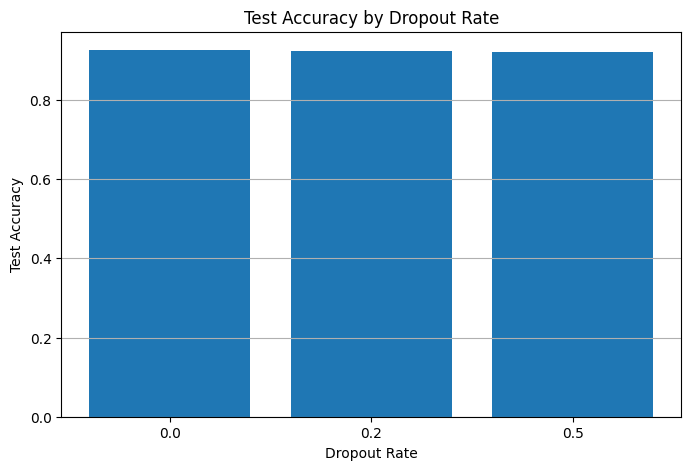

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(lr_results_df["Learning Rate"].astype(str), lr_results_df["Test Accuracy"])
plt.title("Test Accuracy by Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.grid(axis='y')
plt.savefig("figures/learning_rate_bar.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(opt_results_df["Optimizer"], opt_results_df["Test Accuracy"])
plt.title("Test Accuracy by Optimizer")
plt.xlabel("Optimizer")
plt.ylabel("Test Accuracy")
plt.grid(axis='y')
plt.savefig("figures/optimizer_bar.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(drop_results_df["Dropout Rate"].astype(str), drop_results_df["Test Accuracy"])
plt.title("Test Accuracy by Dropout Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Accuracy")
plt.grid(axis='y')
plt.savefig("figures/dropout_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Best Model Analysis

The best-performing model from the dropout experiment is analysed further using a confusion matrix and classification report.

In [ ]:
best_dropout = drop_results_df.sort_values("Test Accuracy", ascending=False).iloc[0]["Dropout Rate"]
best_model = drop_models[best_dropout]

print(f"Best-performing dropout setting: {best_dropout}")

Best-performing dropout setting: 0.0


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


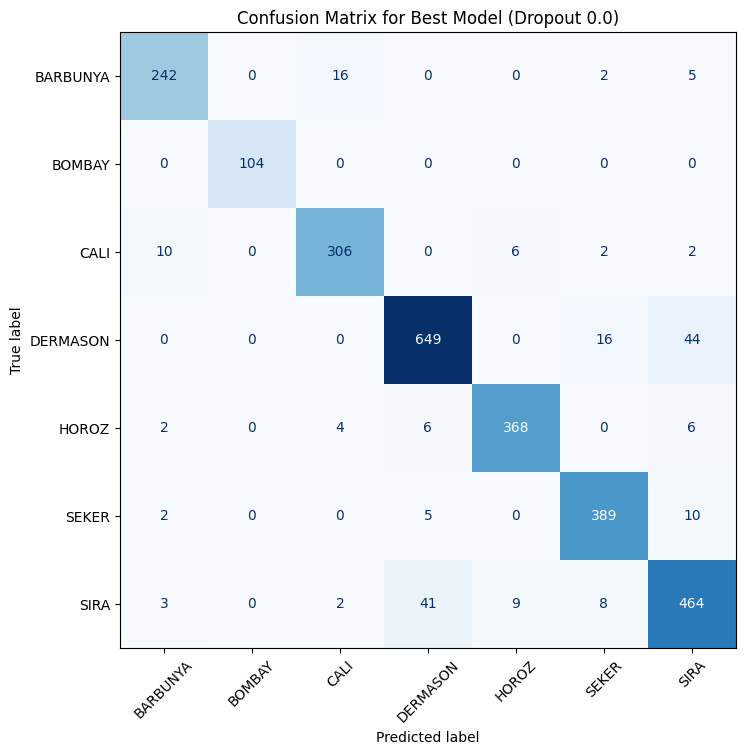

In [ ]:
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"Confusion Matrix for Best Model (Dropout {best_dropout})")
plt.savefig("figures/confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.93      0.92      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.96      0.95       406
        SIRA       0.87      0.88      0.88       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



# Final Reflection

These experiments show that optimisation choices can significantly affect model behaviour even when the architecture remains unchanged.

In this case, the strongest and most stable results were achieved using:
- **Adam**
- **learning rate = 0.001**
- **dropout = 0.2**

This reinforces the importance of controlled experimentation when tuning neural networks.